# Exact Line Search for $\alpha$

> 📖 Book: [ch04](../../.claude/skills/ml-knowledge/chapters/ch04-linear-regression-gradient-descent.md) · Prev: [03](03_gd_fixed_step.ipynb) · Next: [05 Quadratic interpolation, CG, BFGS](05_gd_quadratic_interp_cg_bfgs.ipynb)

If $J$ is a convex paraboloid we can find the optimal $\alpha$ at each step. Define the auxiliary one-dimensional function

$$
\varphi(\alpha) = J\left[\theta_k - \alpha\nabla J(\theta_k)\right].
$$

By the chain rule its minimum satisfies

$$
\varphi'(\alpha) = -\nabla J\left(\theta_k - \alpha\nabla J(\theta_k)\right)\cdot\nabla J(\theta_k) = -\nabla J(\theta_{k+1})\cdot\nabla J(\theta_k) = 0 ,
$$

so **consecutive gradients are orthogonal**.

Multiply $\theta_{k+1} = \theta_k - \alpha\nabla J(\theta_k)$ by $A$ and subtract $b$:

$$
A\theta_{k+1} - b = A\theta_k - b - \alpha A\nabla J(\theta_k).
$$

With the residuals $r_k = A\theta_k - b = \nabla J(\theta_k)$ and $r_{k+1} = A\theta_{k+1} - b = \nabla J(\theta_{k+1})$:

$$
r_{k+1} = r_k - \alpha A r_k .
$$

Since $r_{k+1}\cdot r_k = 0$, pre-multiply by $r_k^T$:

$$
0 = r_k^Tr_{k+1} = r_k^Tr_k - \alpha\, r_k^TAr_k
\qquad\Longrightarrow\qquad
\boxed{\alpha_k = \frac{\|r_k\|^2}{r_k^TAr_k}} .
$$

We iterate while $\|r_k\|$ is above the tolerance, up to a maximum number of iterations. In code: `gradient_descent(..., step="exact", A=A)`.

## Example

Same paraboloid as before: $J(\theta) = 5\theta_0^2 + \frac12\theta_1^2 - \theta_0 + \theta_1$, i.e. $A = \mathrm{diag}(10, 1)$, $b = (1, -1)^T$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ml.optimization import gradient_descent, quadratic
from ml.visualization.plots import plot_convergence, plot_cost_surface

plt.style.use("seaborn-v0_8-whitegrid")

A = np.array([[10.0, 0.0], [0.0, 1.0]])
b = np.array([1.0, -1.0])
cost, grad = quadratic(A, b)
theta0 = np.array([1.0, 1.0])

theta, hist_exact = gradient_descent(cost, grad, theta0, step="exact", A=A, tol=0.01)
_, hist_fixed = gradient_descent(cost, grad, theta0, alpha=0.17, tol=0.01)
pd.DataFrame(hist_exact, columns=["theta0", "theta1", "J(theta)"])

,theta0,theta1,J(theta)
0,1.000000,1.000000,5.500000
1,0.060197,0.791155,1.062039
2,0.339808,-0.467094,-0.120468
3,0.089394,-0.522742,-0.435550
4,0.163897,-0.858006,-0.519504
5,0.097174,-0.872833,-0.541874
6,0.117026,-0.962165,-0.547835
7,0.099247,-0.966116,-0.549423
8,0.104537,-0.989919,-0.549846
9,0.099799,-0.990972,-0.549959


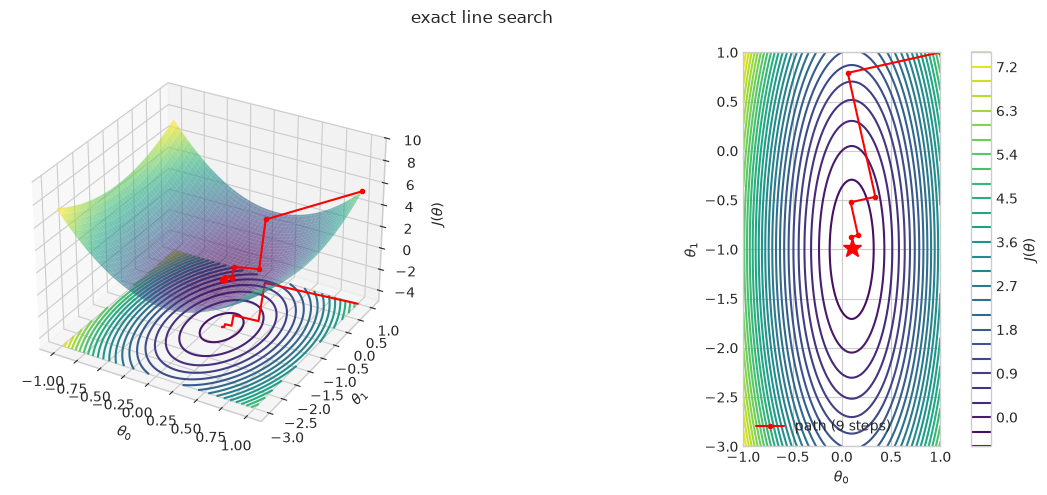

cos(angle) between consecutive steps: [-0.  0. -0. -0. -0. -0.  0. -0.]


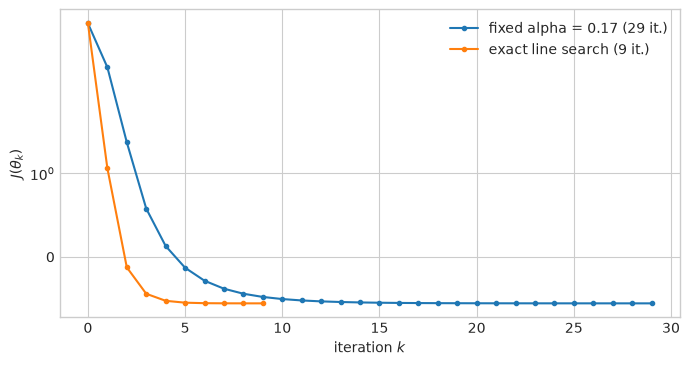

In [2]:
plot_cost_surface(cost, hist_exact, zlim=(-5, 10), title="exact line search")
plt.show()

# consecutive steps are orthogonal
steps = np.diff(hist_exact[:, :2], axis=0)
cosines = np.sum(steps[1:] * steps[:-1], axis=1) / np.linalg.norm(steps[1:], axis=1) / np.linalg.norm(steps[:-1], axis=1)
print("cos(angle) between consecutive steps:", cosines.round(6))

plot_convergence({"fixed alpha = 0.17": hist_fixed, "exact line search": hist_exact})
plt.show()

The path (red) zig-zags with **90° turns** until it gets very close to the analytic minimum $\theta^* = (0.1, -1)^T$. Steepest descent converges for convex functions, but the zig-zag can be expensive – and much worse in high dimensions or for more elongated bowls. The number of zig-zags grows with the condition number: the error shrinks by about $\left(\frac{\kappa - 1}{\kappa + 1}\right)$ per step.

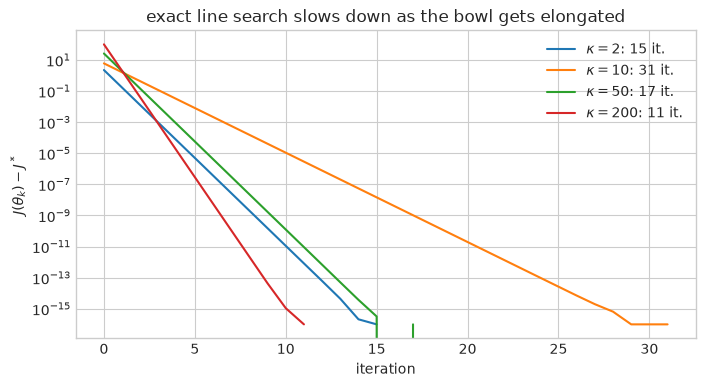

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for kappa in (2, 10, 50, 200):
    Ak = np.diag([float(kappa), 1.0])
    c, g = quadratic(Ak, b)
    _, h = gradient_descent(c, g, theta0, step="exact", A=Ak, tol=1e-8, max_iter=5000)
    ax.semilogy(h[:, -1] - h[-1, -1] + 1e-16, label=rf"$\kappa = {kappa}$: {len(h) - 1} it.")
ax.set(xlabel="iteration", ylabel=r"$J(\theta_k) - J^*$", title="exact line search slows down as the bowl gets elongated")
ax.legend()
plt.show()

The quadratic bowl is a special case where $\alpha$ has a closed form. Real cost functions are not quadratic, so we need another strategy to choose $\alpha$ and control the zig-zag → quadratic interpolation and conjugate directions in the next notebook.